# Spherical Distribution Functions

galpy includes several distribution functions for spherical systems, both
isotropic and anisotropic. These DFs are tied to a specific spherical potential
and can be used to compute properties of the system or to generate samples. 
galpy contains a number of specific isotropic and anisotropic DFs, 
but it also includes a general classes for computing the DF of any spherical system 
using Eddington's formula for isotropic systems and similar formulas for anisotropic systems
with constant anisotropy or anisotropy of the Osipkov-Merritt type. See [galaxiesbook.org](https://galaxiesbook.org/chapters/I-04.-Equilibria-of-Collisionless-Stellar-Systems_6-Spherical-distribution-functions.html) for more details on these DFs and the underlying theory.

In [1]:
%matplotlib inline
import numpy
import matplotlib.pyplot as plt
from galpy.util.quadpack import AccuracyWarning
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=AccuracyWarning)

## Isotropic Hernquist DF

The `isotropicHernquistdf` is initialized from a `HernquistPotential` instance.
The DF is a function of energy only, $f(E)$, corresponding to an isotropic
velocity distribution.

In [2]:
from galpy.potential import HernquistPotential
from galpy.df import isotropicHernquistdf

hp = HernquistPotential(amp=2.0, a=1.3)
dfh = isotropicHernquistdf(pot=hp)

### Evaluating the DF as a function of energy

The DF can be evaluated at a given (relative) energy $E$. The relative energy
is defined as $E = \Psi(r) - \frac{1}{2}v^2$ where $\Psi = -\Phi$ is the
relative potential:

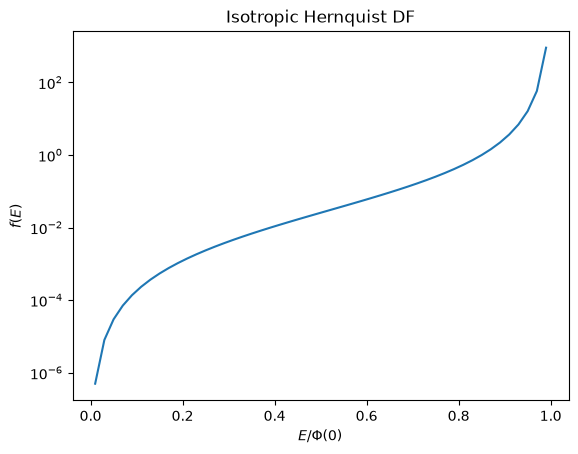

In [3]:
# Evaluate at several energies
Es = numpy.linspace(0.01, 0.99, 50)
# Scale by Phi(0) to get the DF as a function of energy
phi0 = hp(0.0, 0.0, use_physical=False)
fE = numpy.array([dfh.fE(E * phi0) for E in Es])
plt.semilogy(Es, fE)
plt.xlabel(r"$E / \Phi(0)$")
plt.ylabel(r"$f(E)$")
plt.title("Isotropic Hernquist DF");

### Sampling positions and velocities

The `sample` method draws random phase-space points from the DF.
By default it returns an `Orbit` object:

In [4]:
numpy.random.seed(1)
samples = dfh.sample(n=5000)
print("Type:", type(samples))
print("Number of orbits:", len(samples))

Type: <class 'galpy.orbit.Orbits.Orbit'>
Number of orbits: 5000


Let's plot the spatial distribution of the sampled orbits:

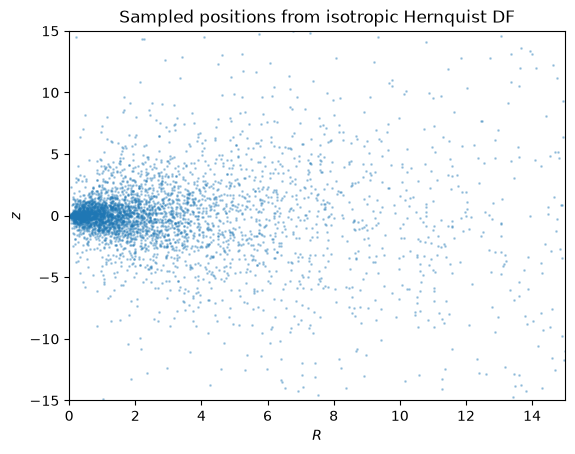

In [5]:
# Plot the spatial distribution
Rs = samples.R()
zs = samples.z()
plt.scatter(Rs, zs, s=1, alpha=0.3)
plt.xlabel(r"$R$")
plt.ylabel(r"$z$")
plt.title("Sampled positions from isotropic Hernquist DF")
plt.xlim(0, 15)
plt.ylim(-15, 15);

### Velocity dispersion profile

We can compare the velocity dispersion profile of the samples to the
analytical prediction. The `sigmar` method computes $\sigma_r(r)$:

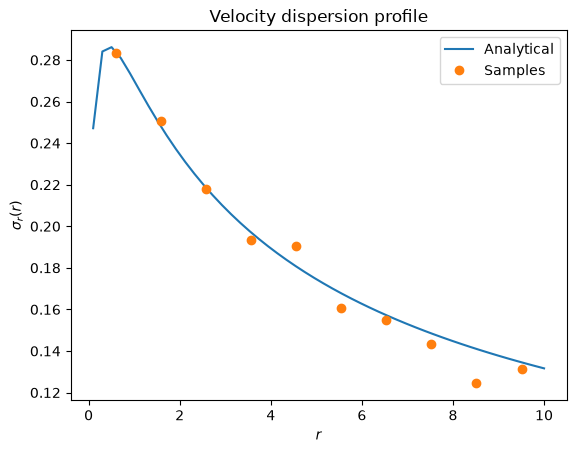

In [6]:
# Analytical velocity dispersion
rs = numpy.linspace(0.1, 10.0, 50)
sigmar = numpy.array([dfh.sigmar(r) for r in rs])

# Velocity dispersion from samples
r_samples = samples.r()
vr_samples = (
    samples.x() * samples.vx() + samples.y() * samples.vy() + samples.z() * samples.vz()
) / r_samples

# Bin the samples
rbins = numpy.linspace(0.1, 10.0, 11)
rmid = 0.5 * (rbins[:-1] + rbins[1:])
sig_binned = numpy.zeros(len(rmid))
for i in range(len(rmid)):
    mask = (r_samples >= rbins[i]) & (r_samples < rbins[i + 1])
    if numpy.sum(mask) > 2:
        sig_binned[i] = numpy.std(vr_samples[mask])

plt.plot(rs, sigmar, label="Analytical")
plt.plot(rmid, sig_binned, "o", label="Samples")
plt.xlabel(r"$r$")
plt.ylabel(r"$\sigma_r(r)$")
plt.legend()
plt.title("Velocity dispersion profile");

## Jeans equation tools

galpy also provides tools for computing velocity moments from the Jeans equation
in `galpy.df.jeans`. These are useful for comparing with DF-based calculations
and for quick estimates when a full DF is not needed.

The main functions are:
- `jeans.sigmar(pot, r)`: radial velocity dispersion $\sigma_r(r)$
- `jeans.sigmalos(pot, R)`: line-of-sight velocity dispersion $\sigma_\mathrm{los}(R)$

Both of these functions allow the user to specify the anisotropy profile $\beta(r)$, which is defined as
$\beta(r) = 1 - \frac{\sigma_\theta^2 + \sigma_\phi^2}{2\sigma_r^2}$ as well as the tracer density profile $\nu(r)$, which is needed to solve the Jeans equation. By default, `beta` is set to 0 (isotropic) and `nu` is set to the density profile of the potential.

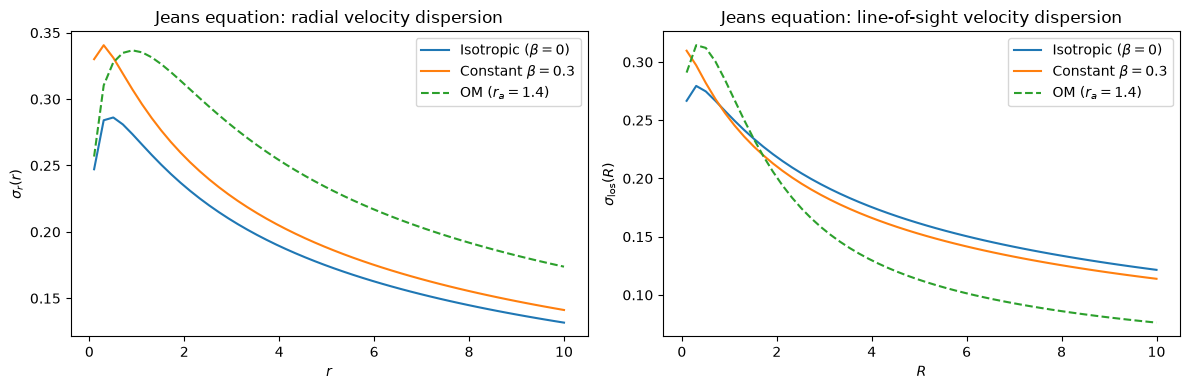

In [7]:
from galpy.df import jeans

# Compute radial velocity dispersion from the Jeans equation
rs_jeans = numpy.linspace(0.1, 10.0, 50)
sigmar_jeans = numpy.array([jeans.sigmar(hp, r, use_physical=False) for r in rs_jeans])

# Compute for constant beta=0.3
sigmar_jeans_b03 = numpy.array(
    [jeans.sigmar(hp, r, beta=0.3, use_physical=False) for r in rs_jeans]
)

# Compute for Osipkov-Merritt-style beta(r) = r^2/(r^2 + ra^2)
beta_om = lambda r: r**2 / (r**2 + 1.4**2)
sigmar_jeans_om = numpy.array(
    [jeans.sigmar(hp, r, beta=beta_om, use_physical=False) for r in rs_jeans]
)

# Compute line-of-sight velocity dispersion
sigmalos_jeans = numpy.array(
    [jeans.sigmalos(hp, R, use_physical=False) for R in rs_jeans]
)
sigmalos_jeans_b03 = numpy.array(
    [jeans.sigmalos(hp, R, beta=0.3, use_physical=False) for R in rs_jeans]
)
sigmalos_jeans_om = numpy.array(
    [jeans.sigmalos(hp, R, beta=beta_om, use_physical=False) for R in rs_jeans]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(rs_jeans, sigmar_jeans, label=r"Isotropic ($\beta=0$)")
axes[0].plot(rs_jeans, sigmar_jeans_b03, label=r"Constant $\beta=0.3$")
axes[0].plot(rs_jeans, sigmar_jeans_om, "--", label=r"OM ($r_a=1.4$)")
axes[0].set_xlabel(r"$r$")
axes[0].set_ylabel(r"$\sigma_r(r)$")
axes[0].set_title("Jeans equation: radial velocity dispersion")
axes[0].legend()

axes[1].plot(rs_jeans, sigmalos_jeans, label=r"Isotropic ($\beta=0$)")
axes[1].plot(rs_jeans, sigmalos_jeans_b03, label=r"Constant $\beta=0.3$")
axes[1].plot(rs_jeans, sigmalos_jeans_om, "--", label=r"OM ($r_a=1.4$)")
axes[1].set_xlabel(r"$R$")
axes[1].set_ylabel(r"$\sigma_\mathrm{los}(R)$")
axes[1].set_title("Jeans equation: line-of-sight velocity dispersion")
axes[1].legend()
fig.tight_layout();

## King DF

The King DF models a tidally-truncated, lowered-isothermal distribution.
It is initialized with the dimensionless central potential $W_0$, total mass, and
tidal radius:

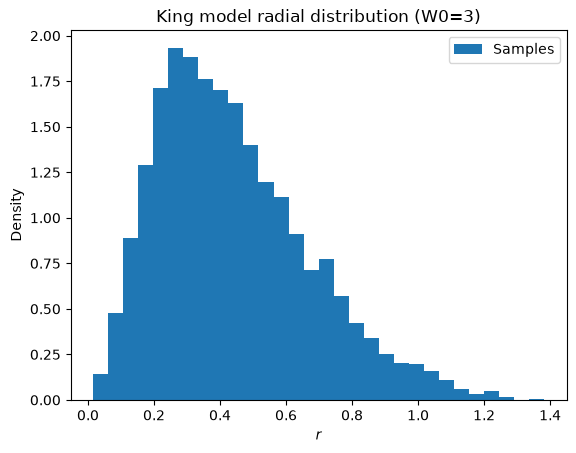

In [8]:
numpy.random.seed(1)
from galpy.df import kingdf

kdf = kingdf(W0=3.0, M=1.0, rt=1.5)

# Sample from the King model
king_samples = kdf.sample(n=5000)
r_king = king_samples.r()
plt.hist(r_king, bins=30, density=True, label="Samples")
plt.xlabel(r"$r$")
plt.ylabel("Density")
plt.title("King model radial distribution (W0=3)")
plt.legend();

We can compare the sampled radial distribution with the theoretical King density
profile. The King DF provides a `dens(r)` method that returns the density at a
given radius. To compare with the histogram of radii, we need to weight by the
volume element $4\pi r^2$:

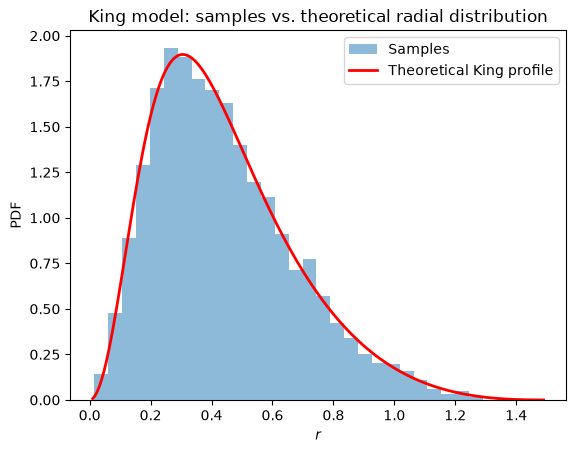

In [9]:
# Theoretical King density profile weighted by volume element
r_theory = numpy.linspace(0.01, 1.49, 200)
rho_theory = numpy.array([kdf.dens(r) for r in r_theory])
# The histogram shows the PDF of radii, which is proportional to rho(r) * 4*pi*r^2
radial_pdf = rho_theory * 4.0 * numpy.pi * r_theory**2
# Normalize to integrate to 1 (since histogram is density=True)
from scipy import integrate

radial_pdf /= integrate.trapezoid(radial_pdf, r_theory)

plt.hist(r_king, bins=30, density=True, alpha=0.5, label="Samples")
plt.plot(r_theory, radial_pdf, "r-", lw=2, label="Theoretical King profile")
plt.xlabel(r"$r$")
plt.ylabel("PDF")
plt.title("King model: samples vs. theoretical radial distribution")
plt.legend();

## Differential energy distribution

galpy can also compute the differential energy distribution $N(E)$, which is the number of stars per unit energy. This is related to the DF by integrating over phase space at fixed energy:

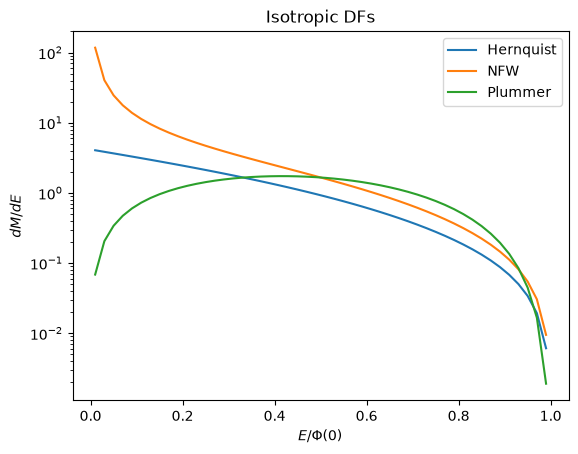

In [10]:
hp = HernquistPotential(amp=2.0, a=1.3)
dfh = isotropicHernquistdf(pot=hp)

from galpy.potential import NFWPotential, PlummerPotential
from galpy.df import isotropicNFWdf, isotropicPlummerdf

nfp = NFWPotential(amp=1.0, a=1.0)
dfnfw = isotropicNFWdf(pot=nfp)
pp = PlummerPotential(amp=1.0, b=1.0)
dfplummer = isotropicPlummerdf(pot=pp)

# Evaluate at several energies
Es = numpy.linspace(0.01, 0.99, 50)
# Scale by Phi(0) to get the DF as a function of energy
phi0_hp = hp(0.0, 0.0, use_physical=False)
dMdE_hp = numpy.array([dfh.dMdE(E * phi0_hp) for E in Es])
phi0_nfw = nfp(0.0, 0.0, use_physical=False)
dMdE_nfw = numpy.array([dfnfw.dMdE(E * phi0_nfw) for E in Es])
phi0_plummer = pp(0.0, 0.0, use_physical=False)
dMdE_plummer = numpy.array([dfplummer.dMdE(E * phi0_plummer) for E in Es])
plt.semilogy(Es, dMdE_hp, label="Hernquist")
plt.semilogy(Es, dMdE_nfw, label="NFW")
plt.semilogy(Es, dMdE_plummer, label="Plummer")
plt.xlabel(r"$E / \Phi(0)$")
plt.ylabel(r"$dM/dE$")
plt.title("Isotropic DFs")
plt.legend();

## Using the Eddington inversion

The ``eddingtondf`` class can be used to compute the isotropic DF for any spherical potential using Eddington's formula. This is useful for potentials that do not have an analytical DF, for comparing with the analytical DFs of specific potentials, or for computing the DFs of tracers in a given potential, e.g., a Hernquist population in an NFW potential. We give an example of the latter here:

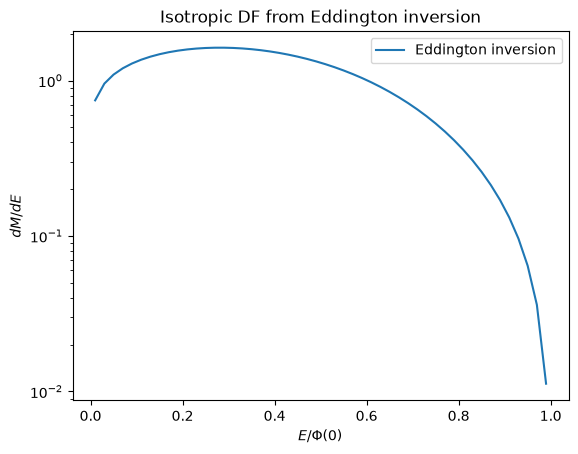

In [11]:
from galpy.df import eddingtondf

nfp = NFWPotential(amp=1.0, a=1.0)
hp = HernquistPotential(amp=2.0, a=1.3)
df_edd = eddingtondf(pot=nfp, denspot=hp)
Es = numpy.linspace(0.01, 0.99, 50)
phi0_nfw = nfp(0.0, 0.0, use_physical=False)
dMdE_edd = numpy.array([df_edd.dMdE(E * phi0_nfw) for E in Es])
plt.semilogy(Es, dMdE_edd, label="Eddington inversion")
plt.xlabel(r"$E / \Phi(0)$")
plt.ylabel(r"$dM/dE$")
plt.title("Isotropic DF from Eddington inversion")
plt.legend();

## Anisotropic DFs

galpy includes anisotropic DFs for spherical systems.

### Constant-beta Hernquist DF

The `constantbetaHernquistdf` implements a Hernquist DF with constant velocity
anisotropy parameter $\beta$. Unlike the isotropic case ($\beta=0$), this DF
has different radial and tangential velocity dispersions. The anisotropy
parameter is defined as $\beta = 1 - \sigma_t^2 / (2\sigma_r^2)$, so
$\beta > 0$ corresponds to radially-biased orbits and $\beta < 0$ to
tangentially-biased orbits.

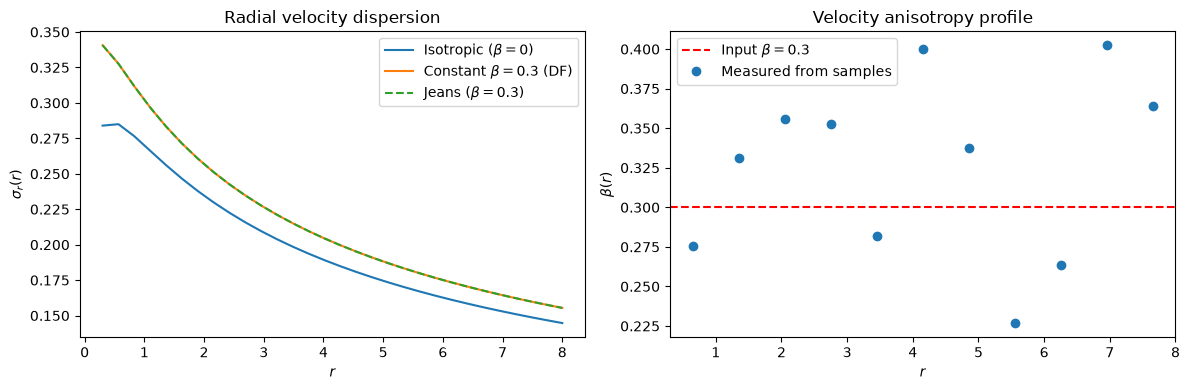

In [12]:
numpy.random.seed(1)
from galpy.df import constantbetaHernquistdf

hp = HernquistPotential(amp=2.0, a=1.3)
dfb = constantbetaHernquistdf(pot=hp, beta=0.3)

# Sample and compute the velocity anisotropy from samples
samples_b = dfb.sample(n=10000)
r_b = samples_b.r()
vr_b = samples_b.vr()
vt2_b = samples_b.vx() ** 2 + samples_b.vy() ** 2 + samples_b.vz() ** 2 - vr_b**2

# Compare analytical sigma_r with isotropic and Jeans equation
rs = numpy.linspace(0.3, 8.0, 30)
sigmar_beta = numpy.array([dfb.sigmar(r) for r in rs])
sigmar_iso = numpy.array([dfh.sigmar(r) for r in rs])
sigmar_jeans_beta = numpy.array(
    [jeans.sigmar(hp, r, beta=0.3, use_physical=False) for r in rs]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left panel: velocity dispersion comparison
axes[0].plot(rs, sigmar_iso, label=r"Isotropic ($\beta=0$)")
axes[0].plot(rs, sigmar_beta, label=r"Constant $\beta=0.3$ (DF)")
axes[0].plot(rs, sigmar_jeans_beta, "--", label=r"Jeans ($\beta=0.3$)")
axes[0].set_xlabel(r"$r$")
axes[0].set_ylabel(r"$\sigma_r(r)$")
axes[0].legend()
axes[0].set_title("Radial velocity dispersion")

# Right panel: measured anisotropy from samples
rbins = numpy.linspace(0.3, 8.0, 12)
rmid = 0.5 * (rbins[:-1] + rbins[1:])
beta_measured = numpy.zeros(len(rmid))
for i in range(len(rmid)):
    mask = (r_b >= rbins[i]) & (r_b < rbins[i + 1])
    if numpy.sum(mask) > 10:
        sig_r2 = numpy.var(vr_b[mask])
        sig_t2 = numpy.mean(vt2_b[mask])
        beta_measured[i] = 1.0 - sig_t2 / (2.0 * sig_r2)

axes[1].axhline(0.3, color="r", ls="--", label=r"Input $\beta=0.3$")
axes[1].plot(rmid, beta_measured, "o", label="Measured from samples")
axes[1].set_xlabel(r"$r$")
axes[1].set_ylabel(r"$\beta(r)$")
axes[1].legend()
axes[1].set_title("Velocity anisotropy profile")
fig.tight_layout();

### Osipkov-Merritt Hernquist DF

The Osipkov-Merritt DF is a widely used model for radially-anisotropic
spherical systems. The velocity anisotropy varies with radius as
$\beta(r) = r^2/(r^2 + r_a^2)$, where $r_a$ is the anisotropy radius.
This means the system is nearly isotropic at the center ($r \ll r_a$)
and becomes increasingly radially anisotropic at large radii ($r \gg r_a$,
$\beta \to 1$). Smaller values of $r_a$ lead to stronger overall anisotropy.

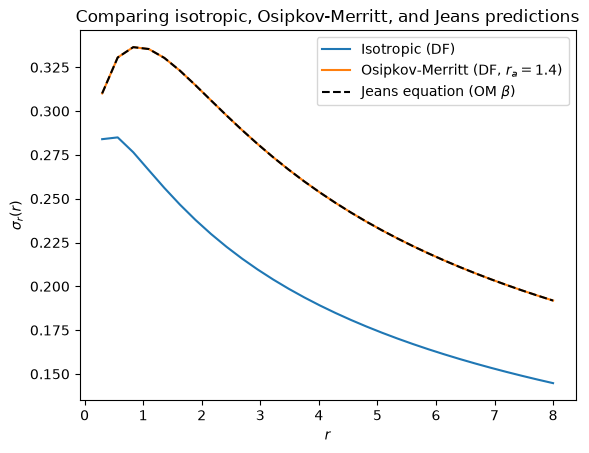

In [13]:
from galpy.df import osipkovmerrittHernquistdf

dfom = osipkovmerrittHernquistdf(pot=hp, ra=1.4)

# Compare velocity dispersion profiles: DF vs. Jeans equation
rs = numpy.linspace(0.3, 8.0, 30)
sig_iso = numpy.array([dfh.sigmar(r) for r in rs])
sig_om = numpy.array([dfom.sigmar(r) for r in rs])

# Jeans equation prediction with the OM beta profile
beta_om = lambda r: r**2 / (r**2 + 1.4**2)
sigmar_jeans_om = numpy.array(
    [jeans.sigmar(hp, r, beta=beta_om, use_physical=False) for r in rs]
)

plt.plot(rs, sig_iso, label="Isotropic (DF)")
plt.plot(rs, sig_om, label="Osipkov-Merritt (DF, $r_a=1.4$)")
plt.plot(rs, sigmar_jeans_om, "k--", label="Jeans equation (OM $\\beta$)")
plt.xlabel(r"$r$")
plt.ylabel(r"$\sigma_r(r)$")
plt.legend()
plt.title("Comparing isotropic, Osipkov-Merritt, and Jeans predictions");

For all anisotropic DFs, the sampling and evaluation methods work similarly to the isotropic case, but the velocity distribution will reflect the specified anisotropy.

We can also compute the differential energy distribution for anisotropic DFs, which will differ from the isotropic case due to the different velocity structure.

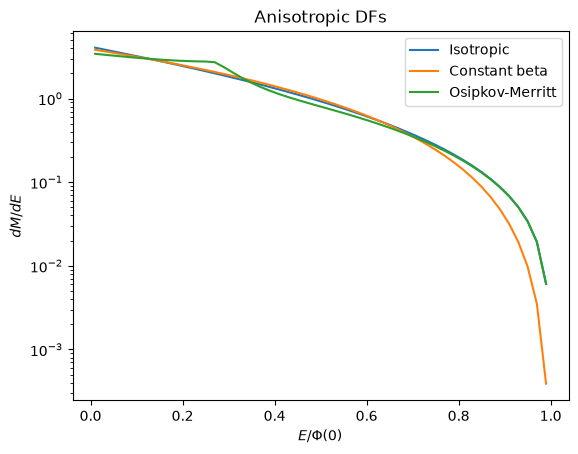

In [14]:
hp = HernquistPotential(amp=2.0, a=1.3)
dfh = isotropicHernquistdf(pot=hp)
dfh_constantbeta = constantbetaHernquistdf(pot=hp, beta=0.5)
dfh_ombeta = osipkovmerrittHernquistdf(pot=hp, ra=1.4)
# Evaluate at several energies
Es = numpy.linspace(0.01, 0.99, 50)
# Scale by Phi(0) to get the DF as a function of energy
phi0_hp = hp(0.0, 0.0, use_physical=False)
dMdE_hp = numpy.array([dfh.dMdE(E * phi0_hp) for E in Es])
dMdE_constantbeta = numpy.array([dfh_constantbeta.dMdE(E * phi0_hp) for E in Es])
dMdE_ombeta = numpy.array([dfh_ombeta.dMdE(E * phi0_hp) for E in Es])
plt.semilogy(Es, dMdE_hp, label="Isotropic")
plt.semilogy(Es, dMdE_constantbeta, label="Constant beta")
plt.semilogy(Es, dMdE_ombeta, label="Osipkov-Merritt")
plt.xlabel(r"$E / \Phi(0)$")
plt.ylabel(r"$dM/dE$")
plt.title("Anisotropic DFs")
plt.legend();

General formulas for computing constant-ansisotropy and Osipkov-Merritt DFs for any spherical potential are also implemented in the `constantbetadf` and `osipkovmerrittdf` classes, which can be used to compute the DF for any spherical potential with the specified anisotropy profile. For example, again embedding a Hernquist population in an NFW potential, we can compute the constant-beta and Osipkov-Merritt DFs for this system as follows and sample the different DFs to compare their velocity distributions:

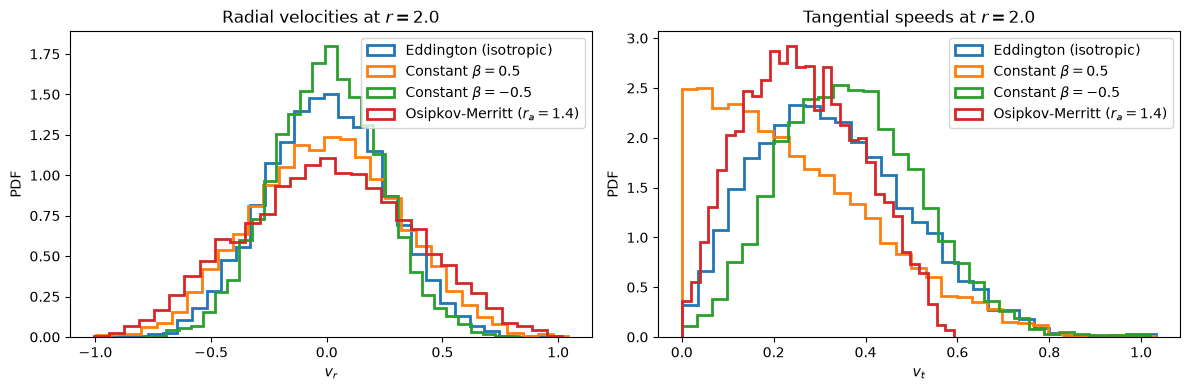

In [15]:
from galpy.df import constantbetadf, osipkovmerrittdf

r0 = 2.0
n_samples = 8000
numpy.random.seed(1)

nfp = NFWPotential(amp=1.0, a=1.0)
hp = HernquistPotential(amp=2.0, a=1.3)
df_edd = eddingtondf(pot=nfp, denspot=hp)
# Use half-integer beta, for which the numerics are much faster
df_constb = constantbetadf(pot=nfp, denspot=hp, twobeta=1)
df_constb_low = constantbetadf(pot=nfp, denspot=hp, twobeta=-1)
df_omb = osipkovmerrittdf(pot=nfp, denspot=hp, ra=1.4)

samples_edd = df_edd.sample(n=n_samples, R=r0, z=0.0)
samples_constb = df_constb.sample(n=n_samples, R=r0, z=0.0)
samples_constb_low = df_constb_low.sample(n=n_samples, R=r0, z=0.0)
samples_omb = df_omb.sample(n=n_samples, R=r0, z=0.0)

vr_edd = samples_edd.vr()
vr_constb = samples_constb.vr()
vr_constb_low = samples_constb_low.vr()
vr_omb = samples_omb.vr()

vt_edd = numpy.sqrt(samples_edd.vT() ** 2 + samples_edd.vtheta() ** 2)
vt_constb = numpy.sqrt(samples_constb.vT() ** 2 + samples_constb.vtheta() ** 2)
vt_constb_low = numpy.sqrt(
    samples_constb_low.vT() ** 2 + samples_constb_low.vtheta() ** 2
)
vt_omb = numpy.sqrt(samples_omb.vT() ** 2 + samples_omb.vtheta() ** 2)

fig_vel, ax_vel = plt.subplots(1, 2, figsize=(12, 4))

ax_vel[0].hist(
    vr_edd, bins=31, density=True, histtype="step", lw=2, label="Eddington (isotropic)"
)
ax_vel[0].hist(
    vr_constb,
    bins=31,
    density=True,
    histtype="step",
    lw=2,
    label=r"Constant $\beta=0.5$",
)
ax_vel[0].hist(
    vr_constb_low,
    bins=31,
    density=True,
    histtype="step",
    lw=2,
    label=r"Constant $\beta=-0.5$",
)
ax_vel[0].hist(
    vr_omb,
    bins=31,
    density=True,
    histtype="step",
    lw=2,
    label=r"Osipkov-Merritt ($r_a=1.4$)",
)
ax_vel[0].set_xlabel(r"$v_r$")
ax_vel[0].set_ylabel("PDF")
ax_vel[0].set_title(rf"Radial velocities at $r={r0}$")
ax_vel[0].legend()

ax_vel[1].hist(
    vt_edd, bins=31, density=True, histtype="step", lw=2, label="Eddington (isotropic)"
)
ax_vel[1].hist(
    vt_constb,
    bins=31,
    density=True,
    histtype="step",
    lw=2,
    label=r"Constant $\beta=0.5$",
)
ax_vel[1].hist(
    vt_constb_low,
    bins=31,
    density=True,
    histtype="step",
    lw=2,
    label=r"Constant $\beta=-0.5$",
)
ax_vel[1].hist(
    vt_omb,
    bins=31,
    density=True,
    histtype="step",
    lw=2,
    label=r"Osipkov-Merritt ($r_a=1.4$)",
)
ax_vel[1].set_xlabel(r"$v_t$")
ax_vel[1].set_ylabel("PDF")
ax_vel[1].set_title(rf"Tangential speeds at $r={r0}$")
ax_vel[1].legend()

fig_vel.tight_layout();

Note that the calculation of constant-anisotropy DFs in this way requires the [jax](https://github.com/google/jax) library to be installed, as it relies on automatic differentiation to compute the necessary derivatives of the potential and density profiles. The Osipkov-Merritt DFs can be computed without ``jax``. Both can be quite slow.